In [20]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt



pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [21]:
df = pd.read_csv('BPL_outliers_treated2.csv')

In [22]:
df.shape

(1566, 26)

In [23]:
df.head()

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories,area/bedrooms
0,sage suncity,bhopal,House,105.0,3750,1.0,NaN,NaN,7,5,0,2800.00,NaN,2800.0,NaN,NaN,0,0,0,0,0,0,1,71,Green View Homes,400.000000
1,danish hills view,kolar road,Flat,85.0,6508,2.0,North,New Property,3,3,1,1306.08,NaN,NaN,1306.0,NaN,0,0,0,1,0,1,1,35,Green View Homes,435.360000
2,narmada prem kesar,katara hills,Flat,25.0,2173,3.0,West,New Property,2,2,3,1150.48,1150.0,NaN,850.0,NaN,0,0,0,0,0,0,1,15,Green View Homes,575.240000
3,gurunanak pura independent house,aishbagh,House,65.0,5909,2.0,West,Old Property,4,5,1,1100.02,NaN,2400.0,2200.0,1100.0,0,0,0,1,0,0,0,18,Road Facing Homes,137.502500
4,chuna bhatti,chuna bhatti,House,650.0,16250,3.0,NaN,New Property,6,6,2,4000.00,NaN,NaN,NaN,4000.0,1,1,1,1,0,0,2,10,Road Facing Homes,666.666667


In [24]:
df.isnull().sum()

society                      4
colony                       0
property_type                0
price_outer                  0
price_per_sqft               0
Total Floors                33
Facing                     696
Property Age               137
bedrooms                     0
bathrooms                    0
balconies                    0
area                         0
super_built_up_area       1213
built_up_area             1118
carpet_area                916
plot_area                  834
study room                   0
servant room                 0
store room                   0
pooja room                   0
others                       0
view floor plan              0
furnishing_type              0
luxury_score                 0
Overlooking_Categories       0
area/bedrooms                0
dtype: int64

<Axes: xlabel='super_built_up_area', ylabel='built_up_area'>

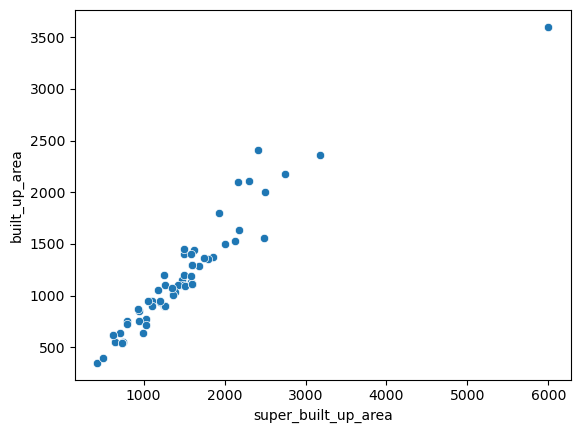

In [25]:
sns.scatterplot(x=df['super_built_up_area'],y=df['built_up_area'])

In [26]:
# there is linear reletionship between super_built_up_area and builtuparea , we will use this to fill builtuparea values.

<Axes: xlabel='carpet_area', ylabel='built_up_area'>

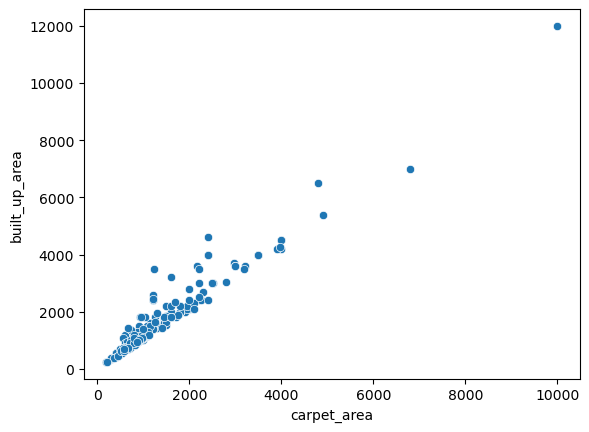

In [27]:
sns.scatterplot(x=df['carpet_area'],y=df['built_up_area'])

<Axes: xlabel='plot_area', ylabel='built_up_area'>

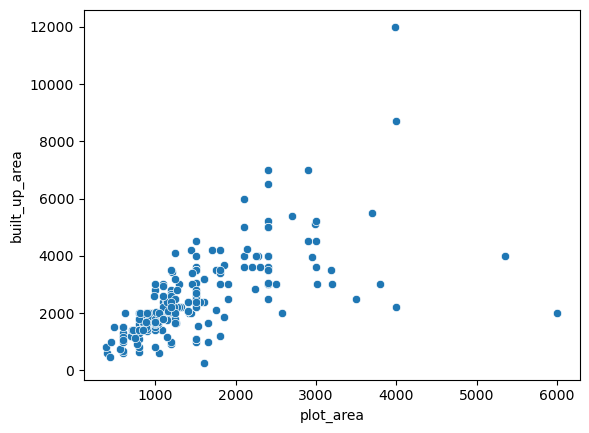

In [28]:
sns.scatterplot(x=df['plot_area'],y=df['built_up_area'])

In [29]:
# where all 4 columns are missing
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()) & (df['plot_area'].isnull())).sum()

0

In [30]:
all_present_df_s = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]
all_present_df_s

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories,area/bedrooms
109,simran residency,govindpura,Flat,31.5,3539,2.0,East,Moderate Property,3,2,2,890.08,1100.0,950.0,890.0,NaN,0,0,1,0,0,0,0,55,Road Facing Homes,296.693333
199,danish nagar d-1,bagmugaliya,Flat,300.0,13888,1.0,NaN,New Property,13,14,2,2160.14,6000.0,3600.0,2160.0,NaN,0,1,0,0,0,0,0,0,Road Facing Homes,166.164615
203,western courtyard,shirdipuram,Flat,100.0,4683,6.0,West,New Property,4,4,1,2135.38,2135.0,1525.0,1300.0,NaN,0,0,0,0,0,0,0,36,Road Facing Homes,533.845000
222,keelandev apartments,central bhopal,Flat,200.0,9237,5.0,East,New Property,4,4,3,2165.21,2165.0,2100.0,2000.0,NaN,1,1,0,1,1,0,0,22,Premium Scenic Homes,541.302500
257,dream luxuria,hoshangabad road,Flat,140.0,5833,8.0,North-East,New Property,4,4,3,2400.14,2415.0,2410.0,2400.0,NaN,1,0,0,1,1,0,1,27,Amenity Facing Homes,600.035000
298,lila atulyam,salaiya,Flat,35.0,2564,5.0,East,New Property,2,2,1,1365.05,1365.0,1011.0,805.0,NaN,0,0,0,0,0,0,1,53,Amenity Facing Homes,682.525000
301,signature 360,katara hills,Flat,31.0,2460,1.0,West,New Property,3,2,2,1260.16,1260.0,1100.0,902.0,NaN,0,0,0,0,0,0,1,45,Amenity Facing Homes,420.053333
307,archana balaji towers,patel nagar,Flat,57.0,2850,1.0,East,Moderate Property,4,4,3,2000.00,2000.0,1500.0,1300.0,NaN,0,0,0,0,0,0,1,11,Road Facing Homes,500.000000
414,regal treasure,ayodhya bypass,Flat,23.9,5975,3.0,South-West,Moderate Property,1,1,2,400.00,650.0,550.0,400.0,NaN,0,0,0,0,0,0,0,35,Road Facing Homes,400.000000
424,sagar life style towers,bawadia kalan,Flat,15.0,3488,5.0,North,Moderate Property,1,1,1,430.05,430.0,350.0,286.0,NaN,0,0,0,0,0,0,1,74,Amenity Facing Homes,430.050000


In [31]:
# where super built up area and built up area not null.
sb = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()))]
sb

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories,area/bedrooms
78,globus coral woods,misrod,Flat,100.00,4593,3.0,NaN,New Property,4,4,2,2177.23,2177.0,1630.0,NaN,NaN,1,0,0,0,0,0,1,30,Amenity Facing Homes,544.307500
109,simran residency,govindpura,Flat,31.50,3539,2.0,East,Moderate Property,3,2,2,890.08,1100.0,950.0,890.0,NaN,0,0,1,0,0,0,0,55,Road Facing Homes,296.693333
151,lila atulyam,salaiya,Flat,57.00,3071,7.0,NaN,New Property,3,3,2,1856.07,1856.0,1375.0,NaN,NaN,0,0,0,0,0,0,1,59,Green View Homes,618.690000
165,satya prakash nice space,gandhinagar,Flat,35.00,2788,3.0,West,New Property,2,2,3,1255.38,1255.0,900.0,NaN,NaN,0,0,0,0,0,0,1,105,Amenity Facing Homes,627.690000
167,swastik grand,misrod,Flat,38.00,2000,6.0,NaN,Moderate Property,3,4,2,1900.00,1800.0,1350.0,NaN,NaN,0,0,0,0,0,0,1,0,Road Facing Homes,633.333333
193,satya prakash nice space,gandhinagar,Flat,45.00,2844,6.0,NaN,New Property,3,3,3,1582.28,1582.0,1130.0,NaN,NaN,0,0,0,0,0,0,1,51,Green View Homes,527.426667
199,danish nagar d-1,bagmugaliya,Flat,300.00,13888,1.0,NaN,New Property,13,14,2,2160.14,6000.0,3600.0,2160.0,NaN,0,1,0,0,0,0,0,0,Road Facing Homes,166.164615
203,western courtyard,shirdipuram,Flat,100.00,4683,6.0,West,New Property,4,4,1,2135.38,2135.0,1525.0,1300.0,NaN,0,0,0,0,0,0,0,36,Road Facing Homes,533.845000
222,keelandev apartments,central bhopal,Flat,200.00,9237,5.0,East,New Property,4,4,3,2165.21,2165.0,2100.0,2000.0,NaN,1,1,0,1,1,0,0,22,Premium Scenic Homes,541.302500
239,gl mid city complex,bhopal,Flat,32.00,2978,2.0,North,Moderate Property,2,2,1,1074.55,940.0,850.0,NaN,NaN,0,0,0,0,0,0,1,12,Road Facing Homes,537.275000


In [32]:
# where carpet area and built up area not null.
cb = df[~((df['carpet_area'].isnull()) | (df['built_up_area'].isnull()))]
cb

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories,area/bedrooms
3,gurunanak pura independent house,aishbagh,House,65.00,5909,2.0,West,Old Property,4,5,1,1100.02,NaN,2400.0,2200.0,1100.0,0,0,0,1,0,0,0,18,Road Facing Homes,137.502500
10,chitrance sai vihar,outside bhopal,House,80.00,4210,2.0,North,New Property,3,3,2,1900.24,NaN,3000.0,2200.0,1900.0,0,0,0,0,0,0,0,17,Green View Homes,633.413333
36,laharpur,bagmuliya,House,231.00,9240,2.0,South,Old Property,4,3,2,2500.00,NaN,3000.0,2500.0,2400.0,1,1,0,0,1,0,1,8,Green View Homes,625.000000
45,krishna colony,neelbad,House,59.00,3856,1.0,North,Moderate Property,3,2,0,1530.08,NaN,1530.0,1500.0,1530.0,0,0,0,0,0,0,1,9,Road Facing Homes,510.026667
47,bda flats,piplani,Flat,45.00,3750,1.0,NaN,Old Property,2,1,2,1200.00,NaN,1200.0,1000.0,NaN,0,0,0,0,0,0,1,0,Road Facing Homes,600.000000
49,sanjeev nagar,gandhinagar,House,175.00,3696,1.0,West,New Property,7,6,3,4734.85,NaN,4600.0,2400.0,NaN,0,0,0,0,0,0,1,7,Green View Homes,676.407143
55,new minal residency,bhopal,House,210.00,12580,1.0,West,Old Property,4,3,3,1669.32,NaN,2400.0,2250.0,1550.0,1,0,0,1,0,0,0,24,Green View Homes,417.330000
63,patel nagar colony,patel nagar,House,34.90,5816,2.0,East,New Property,2,2,1,600.07,NaN,800.0,600.0,390.0,0,0,0,0,0,0,0,24,Road Facing Homes,300.035000
75,landmark the prospera,bagmuliya,Flat,42.00,4666,4.0,East,New Property,3,2,2,900.13,NaN,1200.0,900.0,NaN,0,0,0,0,0,0,0,35,Green View Homes,300.043333
90,noor mahal ashok colony,bhopal,House,250.00,9259,1.0,North-East,Old Property,4,3,2,2700.08,NaN,5400.0,4900.0,2700.0,1,1,0,0,0,0,0,27,Green View Homes,675.020000


In [33]:
s_b_area_ratio = (sb['super_built_up_area'] / sb['built_up_area']).median()
b_c_area_ratio = (cb['carpet_area'] / cb['built_up_area']).median()
s_b_area_ratio,b_c_area_ratio

(1.286387886145098, 0.8333333333333334)

In [34]:
# both present but built_up_null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]
sbc_df.shape

(119, 26)

In [35]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/s_b_area_ratio) + (sbc_df['carpet_area']/b_c_area_ratio))/2),inplace=True)

C:\Users\Yogesh\AppData\Local\Temp\ipykernel_24364\1687497122.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/s_b_area_ratio) + (sbc_df['carpet_area']/b_c_area_ratio))/2),inplace=True)


In [36]:
sbc_df

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories,area/bedrooms
2,narmada prem kesar,katara hills,Flat,25.00,2173,3.0,West,New Property,2,2,3,1150.48,1150.0,957.0,850.0,NaN,0,0,0,0,0,0,1,15,Green View Homes,575.240000
113,ville panache,salaiya,Flat,90.00,5142,6.0,NaN,New Property,3,2,3,1750.29,1750.0,1556.0,1460.0,NaN,0,0,0,0,0,0,1,66,Amenity Facing Homes,583.430000
115,agrawal sagar golden palm,katara hills,Flat,25.00,3846,2.0,West,Moderate Property,2,2,1,650.03,1000.0,779.0,650.0,NaN,0,0,0,0,0,0,0,82,Green View Homes,325.015000
120,ibd hallmark citii,mahawadiya,Flat,21.00,1953,3.0,North,Old Property,3,2,1,1075.27,1075.0,876.0,764.0,NaN,0,0,0,0,0,1,1,12,Road Facing Homes,358.423333
155,unitech unihomes,gehu kheda,Flat,22.00,2242,5.0,East,New Property,2,2,3,981.27,981.0,825.0,740.0,NaN,0,0,0,0,0,0,1,41,Amenity Facing Homes,490.635000
156,sarvadharm colony,kolar road,Flat,17.00,2125,2.0,North,Moderate Property,2,2,2,800.00,800.0,743.0,720.0,NaN,0,0,0,0,1,0,0,8,Road Facing Homes,400.000000
157,rosewood enclave,hoshangabad road,Flat,50.00,3125,2.0,NaN,Moderate Property,3,3,2,1600.00,1600.0,1462.0,1400.0,NaN,0,0,0,0,0,0,0,71,Amenity Facing Homes,533.333333
161,fortune divine city,hoshangabad road,Flat,27.00,3020,4.0,NaN,Old Property,2,2,1,894.04,894.0,767.0,700.0,NaN,0,0,0,0,0,0,1,45,Green View Homes,447.020000
162,lakhumal nikhil nestles,hoshangabad road,Flat,33.00,3666,6.0,West,Moderate Property,2,2,1,900.16,1200.0,1006.0,900.0,NaN,0,0,0,0,0,0,0,59,Amenity Facing Homes,450.080000
176,nikhil devalaya pristine,bawadia kalan,Flat,68.00,4689,6.0,East,New Property,3,3,2,1450.20,1850.0,1589.0,1450.0,NaN,0,0,0,0,0,0,0,35,Premium Scenic Homes,483.400000


In [37]:
df.update(sbc_df)

In [38]:
df.isnull().sum()

society                      4
colony                       0
property_type                0
price_outer                  0
price_per_sqft               0
Total Floors                33
Facing                     696
Property Age               137
bedrooms                     0
bathrooms                    0
balconies                    0
area                         0
super_built_up_area       1213
built_up_area              999
carpet_area                916
plot_area                  834
study room                   0
servant room                 0
store room                   0
pooja room                   0
others                       0
view floor plan              0
furnishing_type              0
luxury_score                 0
Overlooking_Categories       0
area/bedrooms                0
dtype: int64

In [39]:
# built_up_area null but super_built_up area present
sb_df = df[(df['built_up_area'].isnull()) & (~df['super_built_up_area'].isnull())]
sb_df.shape

(166, 26)

In [40]:
sb_df['built_up_area'].fillna(sb_df['super_built_up_area']/s_b_area_ratio,inplace=True)

C:\Users\Yogesh\AppData\Local\Temp\ipykernel_24364\4274500127.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_up_area'].fillna(sb_df['super_built_up_area']/s_b_area_ratio,inplace=True)


In [41]:
sb_df.head()

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories,area/bedrooms
14,lakhumal nikhil nestles,hoshangabad road,Flat,33.0,2750,4.0,West,Moderate Property,2,2,2,1200.00,1200.0,932.844605,NaN,NaN,0,0,0,0,0,0,1,69,Amenity Facing Homes,600.00
16,agrawal sagar lakeview homes,ayodhya bypass,Flat,69.0,4162,3.0,NaN,Moderate Property,3,3,3,1657.86,1802.0,1400.821649,NaN,NaN,0,0,1,0,0,0,0,117,Amenity Facing Homes,552.62
17,rudraksh kasturi,salaiya,Flat,68.0,3885,5.0,East,New Property,3,3,2,1750.32,1750.0,1360.398383,NaN,NaN,0,0,0,0,0,0,1,67,Amenity Facing Homes,583.44
30,nirupam royal palms,hoshangabad road,Flat,22.5,2588,4.0,West,Moderate Property,2,1,1,869.40,850.0,660.764929,NaN,NaN,0,0,0,0,0,0,1,51,Amenity Facing Homes,434.70
34,agrawal sagar landmark,ayodhya bypass,Flat,75.0,3797,7.0,North,Moderate Property,4,4,3,1975.24,1975.0,1535.306746,NaN,NaN,0,0,0,0,0,0,0,56,Amenity Facing Homes,493.81


In [42]:
df.update(sb_df)

In [43]:
df.isnull().sum()

society                      4
colony                       0
property_type                0
price_outer                  0
price_per_sqft               0
Total Floors                33
Facing                     696
Property Age               137
bedrooms                     0
bathrooms                    0
balconies                    0
area                         0
super_built_up_area       1213
built_up_area              833
carpet_area                916
plot_area                  834
study room                   0
servant room                 0
store room                   0
pooja room                   0
others                       0
view floor plan              0
furnishing_type              0
luxury_score                 0
Overlooking_Categories       0
area/bedrooms                0
dtype: int64

In [44]:
# built_up_area null but super_built_up area present
cb_df = df[(~df['carpet_area'].isnull()) & (df['built_up_area'].isnull())]
cb_df.shape

(354, 26)

In [45]:
cb_df.head()

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories,area/bedrooms
1,danish hills view,kolar road,Flat,85.0,6508,2.0,North,New Property,3,3,1,1306.08,NaN,NaN,1306.0,NaN,0,0,0,1,0,1,1,35,Green View Homes,435.360000
13,bda gharonda barrai,katara hills,Flat,10.0,2000,3.0,NaN,Moderate Property,1,1,1,500.00,NaN,NaN,500.0,NaN,0,0,0,0,0,0,1,10,Road Facing Homes,500.000000
18,girnar hills,awadhpuri,Flat,23.0,3622,1.0,NaN,Old Property,2,2,2,635.01,NaN,NaN,635.0,NaN,0,0,0,0,0,0,1,33,Amenity Facing Homes,317.505000
23,yashoda desire,bagmuliya,Flat,60.0,3833,1.0,West,New Property,3,3,3,1565.35,NaN,NaN,1565.0,NaN,0,0,0,0,0,0,0,28,Green View Homes,521.783333
27,maharshi patanjali,gandhinagar,Flat,7.0,1272,1.0,NaN,Moderate Property,1,1,1,550.31,NaN,NaN,550.0,NaN,0,0,0,0,0,0,1,0,Road Facing Homes,550.310000


In [46]:
cb_df['built_up_area'].fillna(cb_df['carpet_area']/b_c_area_ratio,inplace=True)

C:\Users\Yogesh\AppData\Local\Temp\ipykernel_24364\2049860434.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cb_df['built_up_area'].fillna(cb_df['carpet_area']/b_c_area_ratio,inplace=True)


In [47]:
cb_df.head()

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories,area/bedrooms
1,danish hills view,kolar road,Flat,85.0,6508,2.0,North,New Property,3,3,1,1306.08,NaN,1567.2,1306.0,NaN,0,0,0,1,0,1,1,35,Green View Homes,435.360000
13,bda gharonda barrai,katara hills,Flat,10.0,2000,3.0,NaN,Moderate Property,1,1,1,500.00,NaN,600.0,500.0,NaN,0,0,0,0,0,0,1,10,Road Facing Homes,500.000000
18,girnar hills,awadhpuri,Flat,23.0,3622,1.0,NaN,Old Property,2,2,2,635.01,NaN,762.0,635.0,NaN,0,0,0,0,0,0,1,33,Amenity Facing Homes,317.505000
23,yashoda desire,bagmuliya,Flat,60.0,3833,1.0,West,New Property,3,3,3,1565.35,NaN,1878.0,1565.0,NaN,0,0,0,0,0,0,0,28,Green View Homes,521.783333
27,maharshi patanjali,gandhinagar,Flat,7.0,1272,1.0,NaN,Moderate Property,1,1,1,550.31,NaN,660.0,550.0,NaN,0,0,0,0,0,0,1,0,Road Facing Homes,550.310000


In [48]:
df.update(cb_df)

In [49]:
df.isnull().sum()

society                      4
colony                       0
property_type                0
price_outer                  0
price_per_sqft               0
Total Floors                33
Facing                     696
Property Age               137
bedrooms                     0
bathrooms                    0
balconies                    0
area                         0
super_built_up_area       1213
built_up_area              479
carpet_area                916
plot_area                  834
study room                   0
servant room                 0
store room                   0
pooja room                   0
others                       0
view floor plan              0
furnishing_type              0
luxury_score                 0
Overlooking_Categories       0
area/bedrooms                0
dtype: int64

In [50]:
# built_up_area missing but plot area present 
p_df = df[(~df['plot_area'].isnull()) & (df['built_up_area'].isnull())]
p_df.shape

(479, 26)

In [51]:
idx = df[(~df['plot_area'].isnull()) & (df['built_up_area'].isnull())].index
df.loc[idx,'built_up_area'] = df.loc[idx,'plot_area']

In [52]:
# p_df['built_up_area'].fillna(p_df['plot_area'],inplace=True)

In [53]:
df.isnull().sum()

society                      4
colony                       0
property_type                0
price_outer                  0
price_per_sqft               0
Total Floors                33
Facing                     696
Property Age               137
bedrooms                     0
bathrooms                    0
balconies                    0
area                         0
super_built_up_area       1213
built_up_area                0
carpet_area                916
plot_area                  834
study room                   0
servant room                 0
store room                   0
pooja room                   0
others                       0
view floor plan              0
furnishing_type              0
luxury_score                 0
Overlooking_Categories       0
area/bedrooms                0
dtype: int64

<Axes: xlabel='carpet_area', ylabel='built_up_area'>

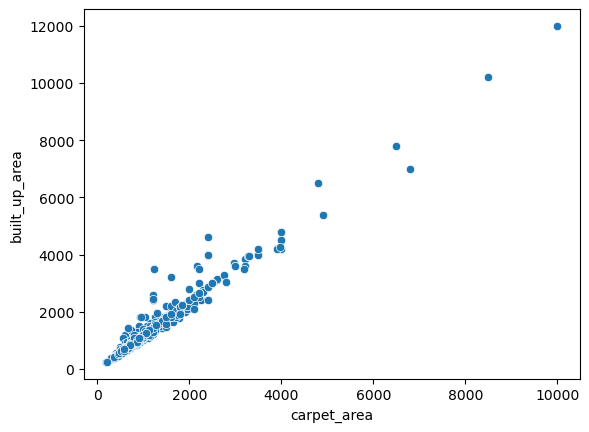

In [54]:
sns.scatterplot(x=df['carpet_area'],y=df['built_up_area'])

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

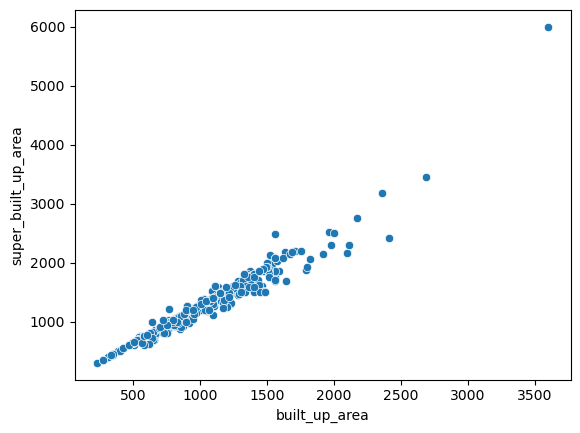

In [55]:
sns.scatterplot(x=df['built_up_area'],y=df['super_built_up_area'])

In [56]:
df.drop(columns=['area','super_built_up_area','carpet_area','plot_area','area/bedrooms'],inplace=True)

In [57]:
df.isnull().sum()

society                     4
colony                      0
property_type               0
price_outer                 0
price_per_sqft              0
Total Floors               33
Facing                    696
Property Age              137
bedrooms                    0
bathrooms                   0
balconies                   0
built_up_area               0
study room                  0
servant room                0
store room                  0
pooja room                  0
others                      0
view floor plan             0
furnishing_type             0
luxury_score                0
Overlooking_Categories      0
dtype: int64

# Total Floors

In [58]:
def Floors_imputations(row,df=df):
    search_df = df.groupby(['colony','property_type'])['Total Floors'].median().reset_index()
    return search_df[(search_df['colony'] == row['colony'])&(search_df['property_type']==row['property_type'])]['Total Floors'].values[0]
    
Floors_imputations(df.loc[9],df)

2.0

In [59]:
df.loc[df['Total Floors'].isnull(), 'Total Floors'] = (
    df[df['Total Floors'].isnull()]
    .apply(Floors_imputations, axis=1)
)

In [60]:
df.isnull().sum()

society                     4
colony                      0
property_type               0
price_outer                 0
price_per_sqft              0
Total Floors                0
Facing                    696
Property Age              137
bedrooms                    0
bathrooms                   0
balconies                   0
built_up_area               0
study room                  0
servant room                0
store room                  0
pooja room                  0
others                      0
view floor plan             0
furnishing_type             0
luxury_score                0
Overlooking_Categories      0
dtype: int64

<Axes: ylabel='count'>

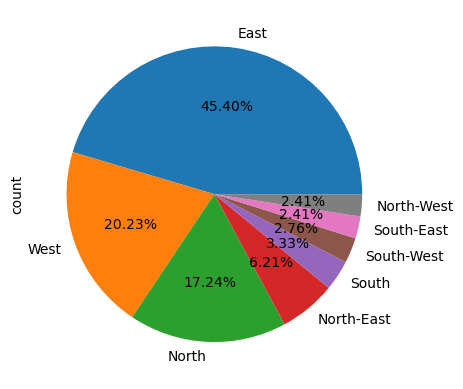

In [61]:
df['Facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [62]:
df['Facing'].isnull().sum()/df.shape[0]
# 44% data is missing so we will drop this column.

0.4444444444444444

In [63]:
df[df['society'].isnull()]

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,built_up_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories
145,NaN,awadhpuri,Flat,22.0,2444,1.0,NaN,NaN,2,2,0,900.0,0,0,0,0,0,0,1,0,Road Facing Homes
243,NaN,piplani,House,60.0,10000,2.0,NaN,Moderate Property,2,2,1,600.0,0,0,0,0,0,0,1,0,Road Facing Homes
390,NaN,shahpura,Flat,21.0,3000,1.0,South-East,NaN,4,3,0,700.0,0,0,0,0,0,0,1,0,Road Facing Homes
1541,NaN,ayodhya bypass,Flat,65.0,4333,1.0,NaN,NaN,3,3,0,1500.0,0,0,0,0,0,0,1,0,Road Facing Homes


In [64]:
df.drop(columns=['society','Facing'],inplace=True)

In [65]:
df.isnull().sum()

colony                      0
property_type               0
price_outer                 0
price_per_sqft              0
Total Floors                0
Property Age              137
bedrooms                    0
bathrooms                   0
balconies                   0
built_up_area               0
study room                  0
servant room                0
store room                  0
pooja room                  0
others                      0
view floor plan             0
furnishing_type             0
luxury_score                0
Overlooking_Categories      0
dtype: int64

# Property Age

In [66]:
def age_imputations(row, df=df):
    search_df = (
        df.groupby(['colony', 'property_type'])['Property Age']
          .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
          .reset_index()
    )
    
    return search_df[
        (search_df['colony'] == row['colony']) &
        (search_df['property_type'] == row['property_type'])
    ]['Property Age'].values[0]

age_imputations(df.loc[0],df)

'Old Property'

In [67]:
df.loc[df['Property Age'].isnull(), 'Property Age'] = (
    df[df['Property Age'].isnull()]
    .apply(age_imputations, axis=1)
)

In [68]:
df[df['Property Age'].isnull()]

,colony,property_type,price_outer,price_per_sqft,Total Floors,Property Age,bedrooms,bathrooms,balconies,built_up_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories


In [69]:
df.isnull().sum()

colony                    0
property_type             0
price_outer               0
price_per_sqft            0
Total Floors              0
Property Age              0
bedrooms                  0
bathrooms                 0
balconies                 0
built_up_area             0
study room                0
servant room              0
store room                0
pooja room                0
others                    0
view floor plan           0
furnishing_type           0
luxury_score              0
Overlooking_Categories    0
dtype: int64

In [70]:
df.to_csv('missing_imputeted_df.csv',index=False)